# Phase 3: Forecast model

**Question:** can we predict tomorrow's hourly count at each CBD sensor better
than a simple rule?

**Set-up (option A).** The council publishes counts once a month. On the day we
forecast, the newest count we could have is about **5 weeks old**. So every
feature built from past counts uses data at least 35 days old. Using last
week's counts in testing would make the model look better than it could ever
be in practice (leakage).

**Test period:** the last 12 months (Oct 2025 – Sep 2026). Training data starts
Oct 2024 (post-COVID only, see Phase 2).

1. Baseline
2. Model (next)

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from melbourne_foot_traffic import config, forecast

con = duckdb.connect(str(config.DB_PATH), read_only=True)

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK2,
    "lines.linewidth": 2, "font.size": 10, "figure.dpi": 110,
})

TEST = ("2025-10-01", "2026-09-30")
names = con.sql("SELECT location_id AS sensor_id, sensor_description AS name FROM sensors").df()

## 1. Baseline

**Rule:** for each sensor and hour, take the average count on the same weekday
5, 6, 7 and 8 weeks earlier. It needs no training and captures each sensor's
daily and weekly rhythm. Any model has to beat it to be worth having.

**Scores:**
- **MAE**: average error in people per hour.
- **WAPE**: total error as a share of total traffic, so busy and quiet sensors
  can be compared. 0.19 means "off by 19% of the traffic".

In [2]:
base = forecast.seasonal_baseline(con, *TEST)
cal = con.sql("SELECT date, is_holiday, holiday_name, school_term FROM calendar").df()
base = base.merge(cal, on="date", how="left")
print(f"{len(base):,} sensor-hours in the test year; baseline missing for {base.baseline.isna().sum()}")
forecast.score(base, "baseline").round(3)

156,014 sensor-hours in the test year; baseline missing for 35


,MAE,WAPE,hours
0,117.063,0.194,155979


In [3]:
forecast.score(base, "baseline", by="is_holiday").round(3)

,MAE,WAPE,hours
is_holiday,,,
False,112.995,0.187,150389
True,226.508,0.373,5590


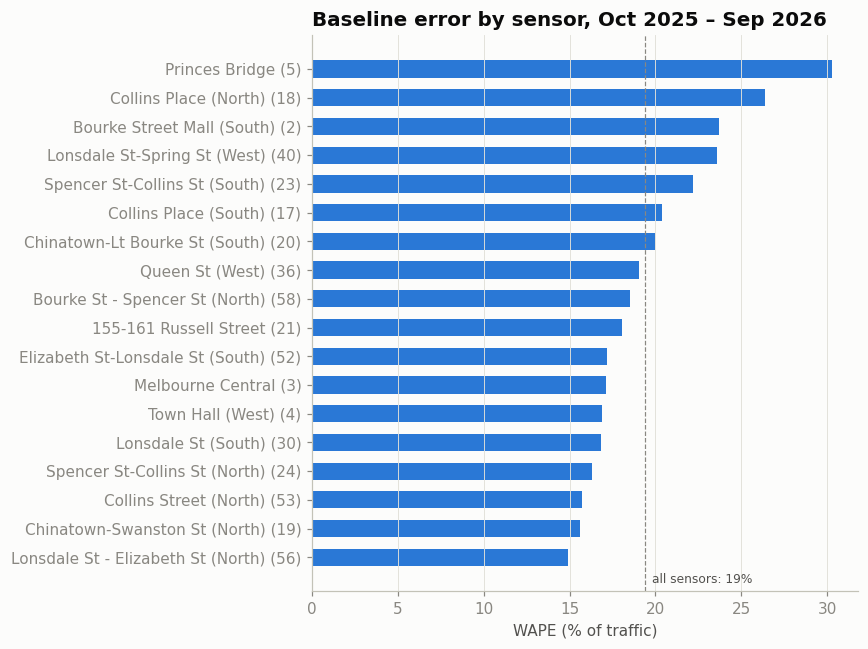

In [4]:
per_sensor = forecast.score(base, "baseline", by="sensor_id").join(names.set_index("sensor_id"))
per_sensor = per_sensor.sort_values("WAPE")

fig, ax = plt.subplots(figsize=(8, 6))
labels = [f"{n} ({i})" for i, n in zip(per_sensor.index, per_sensor.name)]
ax.barh(labels, per_sensor.WAPE * 100, color=BLUE, height=0.6)
overall = forecast.score(base, "baseline").WAPE[0] * 100
ax.axvline(overall, color=MUTED, lw=0.8, ls="--")
ax.text(overall + 0.4, -0.9, f"all sensors: {overall:.0f}%", fontsize=8, color=INK2)
ax.set_xlabel("WAPE (% of traffic)")
ax.set_title("Baseline error by sensor, Oct 2025 – Sep 2026")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Where the baseline fails

The days with the largest error, with that day's weather and holiday status.
These are what the model's features need to explain.

In [5]:
wx = con.sql('''
    SELECT date, max(temperature) AS max_temp, sum(precipitation_mm) AS rain_mm
    FROM weather GROUP BY date
''').df()
daily = (base.dropna(subset=["baseline"])
         .groupby("date")
         .apply(lambda d: pd.Series({
             "actual": d["count"].sum(),
             "baseline": d.baseline.sum(),
             "WAPE": (d.baseline - d["count"]).abs().sum() / d["count"].sum(),
         }), include_groups=False)
         .reset_index()
         .merge(wx, on="date").merge(cal[["date", "holiday_name"]], on="date"))
daily["weekday"] = pd.to_datetime(daily.date).dt.day_name()
daily["actual_vs_baseline"] = (daily.actual / daily.baseline - 1).map("{:+.0%}".format)
daily.sort_values("WAPE", ascending=False).head(12)[
    ["date", "weekday", "actual_vs_baseline", "WAPE", "max_temp", "rain_mm", "holiday_name"]
].round({"WAPE": 2, "max_temp": 1, "rain_mm": 1})

,date,weekday,actual_vs_baseline,WAPE,max_temp,rain_mm,holiday_name
118,2026-01-27,Tuesday,-44%,0.82,43.4,0.0,NaN
85,2025-12-25,Thursday,-20%,0.70,16.1,0.2,Christmas Day
100,2026-01-09,Friday,-40%,0.68,43.2,0.0,NaN
98,2026-01-07,Wednesday,-38%,0.66,41.7,0.0,NaN
92,2026-01-01,Thursday,-9%,0.63,20.2,0.0,New Year's Day
38,2025-11-08,Saturday,-30%,0.56,14.4,21.6,NaN
255,2026-06-13,Saturday,-36%,0.56,17.2,8.0,NaN
246,2026-06-04,Thursday,-34%,0.52,14.2,29.8,NaN
243,2026-06-01,Monday,-29%,0.50,12.7,10.6,NaN
91,2025-12-31,Wednesday,+9%,0.48,17.3,0.5,NaN


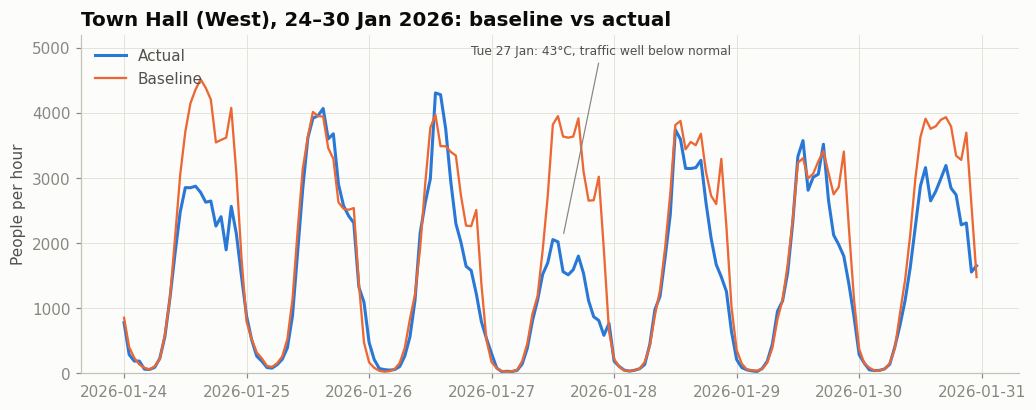

In [6]:
week = base[(base.sensor_id == 4) & (base.date.between("2026-01-24", "2026-01-30"))].copy()
week["ts"] = pd.to_datetime(week.date) + pd.to_timedelta(week.hour, unit="h")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(week.ts, week["count"], color=BLUE, label="Actual")
ax.plot(week.ts, week.baseline, color=ORANGE, label="Baseline", lw=1.5)
ax.set_ylim(0, 5200)
ax.annotate("Tue 27 Jan: 43°C, traffic well below normal", xy=(pd.Timestamp("2026-01-27 14:00"), 2100),
            xytext=(pd.Timestamp("2026-01-26 20:00"), 4900), fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_title("Town Hall (West), 24–30 Jan 2026: baseline vs actual")
ax.set_ylabel("People per hour")
ax.legend(frameon=False, loc="upper left")
plt.show()

**What the baseline misses** (and the model should learn):
- **Heat:** the four worst days of the year were all 41–43°C days in January.
- **Public holidays:** error doubles on holidays (WAPE 0.37 vs 0.19), e.g. Christmas, New Year.
- **Seasonal turns:** in early January the baseline looks back to December
  shopping weeks and over-predicts.
- **Rain:** wet June days.

## 2. Model

*Next: LightGBM with calendar, weather and lagged-count features, tested month
by month on the same test year.*